# Klassificering av ansiktsuttryck med CNN och Deep Learning

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import time

import tensorflow as tf
from sklearn.metrics import accuracy_score

from utils import (
    plot_history,
    predict_classes,
    plot_confusion_matrix,
    calculate_per_class_accuracy,
    get_most_confused_pairs,
    plot_misclassified_examples,
    extract_dataset,
    show_prediction
)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


## 1. Förstå och undersöka datan

### 1.1 Datasetets uppbyggnad

Börjar med att undersöka hur datasetet är uppbyggt

Datasetet är uppdelat i:
- träningsdata (`train`)
- testdata (`test`)

Varje klass ligger i en egen mapp, vilket gör att bilderna automatiskt kan kopplas till rätt etikett vid inläsning.

Därefter undersöks vilka klasser som finns och om train/test innehåller samma etiketter.


In [2]:
data_path = 'Data'

print('Mappar i datasetet:')
print(os.listdir(data_path))


train_path = os.path.join(data_path, 'train')
test_path = os.path.join(data_path, 'test')


classes_train = sorted(os.listdir(train_path))
classes_test = sorted(os.listdir(test_path))

num_classes = len(classes_train)

print('\nAntal klasser:', num_classes)

print('\nKlasser:')
print(classes_train)

print('\nSamma klasser i train och test:')
print(classes_train == classes_test)

Mappar i datasetet:
['test', 'train']

Antal klasser: 7

Klasser:
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Samma klasser i train och test:
True


### 1.2 Klassfördelning i datasetet

För att förstå datans balans analyseras antalet bilder per klass i både tränings- och testdata.

Detta är viktigt eftersom klassobalans kan påverka modellens inlärning och leda till sämre resultat för minoritetsklasser.

In [3]:
data = []

total_train = 0
total_test = 0

for class_name in classes_train:

    train_count = len(os.listdir(os.path.join(train_path, class_name)))
    test_count = len(os.listdir(os.path.join(test_path, class_name)))

    total_train += train_count
    total_test += test_count

    data.append([
        class_name,
        train_count,
        test_count
    ])


df = pd.DataFrame(
    data,
    columns=['Klass', 'Train', 'Test']
)

df['Train %'] = round((df['Train'] / total_train) * 100, 2)
df['Test %'] = round((df['Test'] / total_test) * 100, 2)

df_sorted = df.sort_values("Train", ascending=False)

display(df_sorted)

print(f'Totalt antal träningsbilder: {total_train}')
print(f'Totalt antal testbilder: {total_test}')

,Klass,Train,Test,Train %,Test %
3,happy,7215,1774,25.13,24.71
4,neutral,4965,1233,17.29,17.18
5,sad,4830,1247,16.82,17.37
2,fear,4097,1024,14.27,14.27
0,angry,3995,958,13.92,13.35
6,surprise,3171,831,11.05,11.58
1,disgust,436,111,1.52,1.55


Totalt antal träningsbilder: 28709
Totalt antal testbilder: 7178


### 1.3 Visualisering av klassfördelning

Stapeldiagrammet visar hur bilderna är fördelade mellan klasserna i train och test.

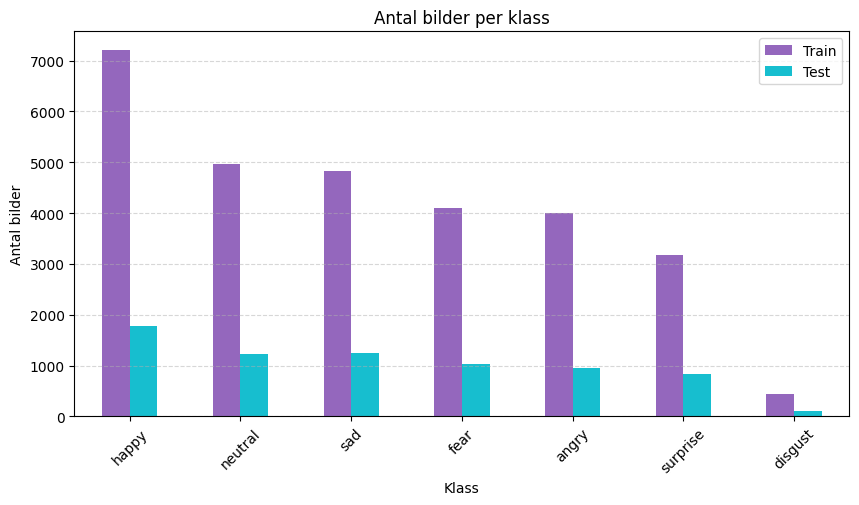

In [4]:
df_sorted.plot(
    x="Klass",
    y=["Train", "Test"],
    kind="bar",
    figsize=(10, 5),
    color=["#9467bd", "#17becf"]
)

plt.title("Antal bilder per klass")
plt.ylabel("Antal bilder")
plt.xticks(rotation=45)
plt.legend(["Train", "Test"])
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

### 1.4 Visuell kontroll av datasetet

Först visas ett exempel från en klass för att kontrollera bildens format och kvalitet.   
Därefter visas ett exempel från varje klass för att få en översikt över variationen i datasetet.

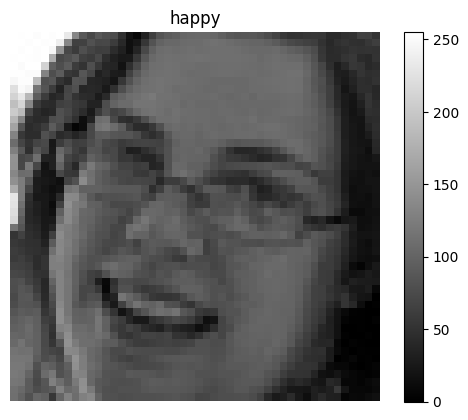

Bildens storlek: (48, 48)


In [5]:
example_class = "happy"
example_path = os.path.join(train_path, example_class)

img_name = os.listdir(example_path)[0]
img_path = os.path.join(example_path, img_name)

img = mpimg.imread(img_path)

plt.imshow(img, cmap="gray")
plt.title(example_class)
plt.colorbar()
plt.axis("off")
plt.show()

print('Bildens storlek:', img.shape)

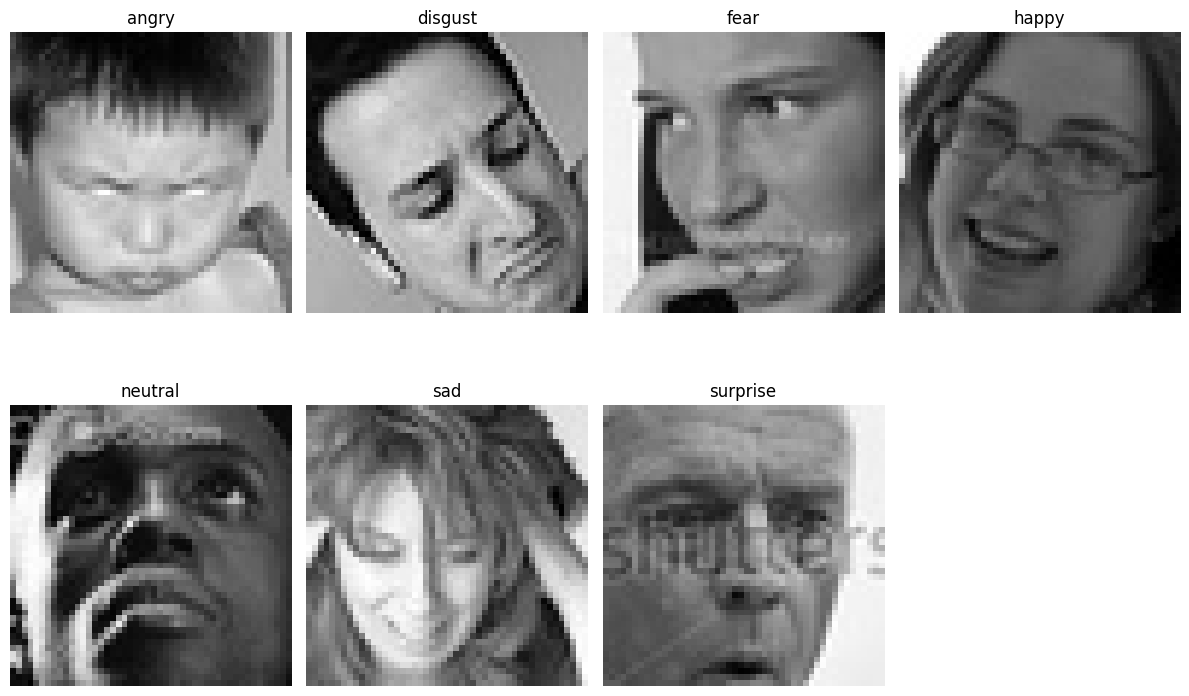

In [6]:
plt.figure(figsize=(12, 8))

for i, c in enumerate(classes_train):
    path = os.path.join(train_path, c)

    img_name = os.listdir(path)[0]
    img_path = os.path.join(path, img_name)

    img = mpimg.imread(img_path)

    plt.subplot(2, 4, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(c)
    plt.axis("off")

plt.tight_layout()
plt.show()

### 1.5 Datasetanalys

Datasetet består av bilder uppdelade i sju olika ansiktsuttryck: angry, disgust, fear, happy, neutral, sad och surprise.  
För varje klass finns både tränings- och testdata.

En analys av klassfördelningen visar att datan är tydligt obalanserad. Vissa klasser, såsom happy och neutral, innehåller betydligt fler bilder än exempelvis disgust och fear.

Denna obalans är viktig att beakta eftersom den kan påverka modellens inlärning. Modellen riskerar att bli bättre på majoritetsklasser och sämre på minoritetsklasser.

Utöver den kvantitativa analysen genomfördes även en visuell granskning av ett urval av bilder från datasetet för att bättre förstå datans karaktär.

Denna inspektion visade att bilderna varierar i både kvalitet, ljussättning och ansiktsposition. Vissa bilder är tydliga och välcentrerade, medan andra innehåller mer brus, låg kontrast eller delvis skymda ansikten.

**Slutsats och lösning**  
För att hantera detta används både modellarkitektur med regularisering samt data augmentation i senare modeller, i syfte att förbättra generalisering och minska överanpassning till dominerande klasser


## 2. Förberedelse av data

### 2.1 Inläsning och uppdelning av dataset

Datasetet läses in med `image_dataset_from_directory`, vilket automatiskt kopplar varje bild till rätt klass baserat på mappstrukturen.

Träningsdatan delas därefter upp i:
- träningsdata
- validationsdata (20 %)

Validation används under träningen för att följa modellens generalisering och upptäcka eventuell overfitting.

Samtliga bilder:
- skalas till 48x48 pixlar
- läses in som gråskalebilder
- batchas i grupper om 32


In [7]:
img_height = 48
img_width = 48
batch_size = 32
seed = 42

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    color_mode="grayscale"
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    color_mode="grayscale"
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    color_mode="grayscale",
    shuffle=False
)

class_names = train_dataset.class_names
print('Klassnamn: ', class_names)

Found 28709 files belonging to 7 classes.
Using 22968 files for training.
Found 28709 files belonging to 7 classes.
Using 5741 files for validation.
Found 7178 files belonging to 7 classes.
Klassnamn:  ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


### 2.2 Normalisering och optimering av dataset

För att stabilisera träningen normaliseras pixelvärdena från intervallet 0–255 till 0–1.  
Detta gör att modellen tränas mer effektivt.

Dataseten optimeras även med prefetch(), vilket förbättrar prestandan genom att förbereda nästa batch medan modellen tränar på den nuvarande.

Slutligen kontrolleras:
- batcharnas dimensioner
- att normaliseringen fungerar korrekt

In [8]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y)).prefetch(AUTOTUNE)

validation_dataset = validation_dataset.map(lambda x, y: (normalization_layer(x), y)).prefetch(AUTOTUNE)

test_dataset = test_dataset.map(lambda x, y: (normalization_layer(x), y)).prefetch(AUTOTUNE)


print('Train dataset batch shape:')
for images, labels in train_dataset.take(1):
    print(images.shape)

print('Pixel range check:')
for images, labels in train_dataset.take(1):
    print("Min:", images.numpy().min(),
          "Max:", images.numpy().max())

Train dataset batch shape:
(32, 48, 48, 1)
Pixel range check:
Min: 0.0 Max: 1.0


### 2.3 Dataset-varianter för experiment

Eftersom datasetet är relativt stort skapas flera mindre versioner av tränings- och validationsdatan.  
Syftet är att snabbare kunna testa olika modeller och minska träningstiden under utvecklingen
- Small v1: används för baseline-modell
- Small v2: används för förbättrad modell
- Full dataset: används för slutliga modeller

**Extraktion av data**  
Extraherar valideringsdata till numpy-format för att möjliggöra utvärdering (accuracy, confusion matrix etc.) .
Detta används i senare analyser där prediktioner jämförs direkt mot sanna etiketter.

**Datasetstorlek och kontroll**  
Slutligen verifieras storleken på varje dataset-variant för att säkerställa korrekt uppdelning.
Detta görs genom att räkna antal batches och multiplicera med batch-storlek.

In [9]:
# SMALL VERSION 1 (baseline)
train_dataset_small_v1 = train_dataset.take(100)
validation_dataset_small_v1 = validation_dataset.take(25)

# SMALL VERSION 2 (improved)
train_dataset_small_v2 = train_dataset.take(200)
validation_dataset_small_v2 = validation_dataset.take(50)

# FULL DATASET (improved_2 + final)
train_dataset_full = train_dataset
validation_dataset_full = validation_dataset


# Baseline eval data
X_val_small_v1, y_val_small_v1 = extract_dataset(validation_dataset_small_v1)

# Improved eval data
X_val_small_v2, y_val_small_v2 = extract_dataset(validation_dataset_small_v2)

# Full eval data
X_val_full, y_val_full = extract_dataset(validation_dataset_full)

print('=== ÖVERBLICK DATASET ===')

for name, train_ds, val_ds in [
    ('v1', train_dataset_small_v1, validation_dataset_small_v1),
    ('v2', train_dataset_small_v2, validation_dataset_small_v2),
    ('full', train_dataset_full, validation_dataset_full)
]:
    train_batches = tf.data.experimental.cardinality(train_ds).numpy()
    val_batches = tf.data.experimental.cardinality(val_ds).numpy()

    print(f"\n{name}")
    print('Antal train bilder:      ', train_batches * batch_size)
    print('Antal validation bilder: ', val_batches * batch_size)

=== ÖVERBLICK DATASET ===

v1
Antal train bilder:       3200
Antal validation bilder:  800

v2
Antal train bilder:       6400
Antal validation bilder:  1600

full
Antal train bilder:       22976
Antal validation bilder:  5760


## 3. Test av olika modeller

I detta steg testas flera CNN-modeller med olika arkitekturer och inställningar för att undersöka hur modellernas prestanda påverkas.

Arbetet börjar med en enklare baseline-modell som sedan förbättras stegvis genom exempelvis:
- större dataset
- fler lager
- dropout
- data augmentation

För att kunna jämföra modellerna skapas en tom lista (`results`) där viktiga resultat från varje modell sparas.

Efter varje träning analyseras modellernas utveckling genom både träningshistorik och prediktioner på valideringsdatan.

Följande analyser genomförs för varje modell:
- tränings- och valideringskurvor analyseras för att identifiera inlärning och eventuell over/underfitting
- den epok med lägst validation loss identifieras för att hitta modellens bästa generalisering
- prediktioner görs på valideringsdatan
- validation accuracy beräknas
- confusion matrix och accuracy per klass analyseras
- vanliga felklassificeringar undersöks
- felklassificerade bilder analyseras visuellt

Detta gör det möjligt att jämföra modellernas styrkor, svagheter och generaliseringsförmåga samt undersöka hur olika arkitektur- och träningsval påverkar resultaten.

### 3.1 Resultatlista för modelljämförelser

En tom lista skapas för att samla resultat från samtliga modeller.
Detta gör det enklare att senare jämföra modellernas prestanda.

In [10]:
results = []

### 3.2.1 Baseline CNN

Den första modellen fungerar som en baseline för senare jämförelser.
Arkitekturen är relativt enkel och används för att skapa en grundnivå att jämföra förbättrade modeller mot.

Modellen består av:
- två convolutional-lager
- max pooling
- ett fullt kopplat dense-lager
- softmax-output för klassificering

In [11]:
base_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(48, 48, 1)),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

base_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

base_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,199,495 (4.58 MB)

 Trainable params: 1,199,495 (4.58 MB)

 Non-trainable params: 0 (0.00 B)

### 3.2.2 Träning av baseline-modellen

Baseline-modellen tränas på den mindre dataset-versionen (small_v1) för snabbare experimentering och kortare träningstid.

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.2681 - loss: 1.8221 - val_accuracy: 0.2700 - val_loss: 1.8188
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.2966 - loss: 1.7413 - val_accuracy: 0.3375 - val_loss: 1.7182
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.3531 - loss: 1.6204 - val_accuracy: 0.3450 - val_loss: 1.6733
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.4219 - loss: 1.5087 - val_accuracy: 0.3613 - val_loss: 1.6477
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.4669 - loss: 1.4097 - val_accuracy: 0.3750 - val_loss: 1.6296
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.5103 - loss: 1.3121 - val_accuracy: 0.3762 - val_loss: 1.6166
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.5584 - loss: 1.2091 - val_accuracy: 0.3375 - val_loss: 1.7968
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.6000 - loss: 1.1026 - val_accu

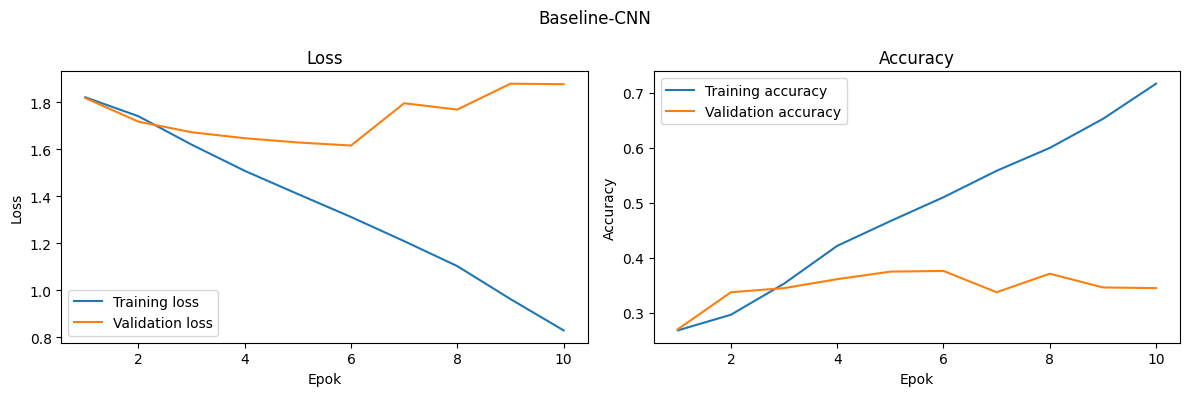

In [12]:
start_time = time.time()

base_history = base_model.fit(
    train_dataset_small_v1,
    validation_data=validation_dataset_small_v1,
    epochs=10
)

training_time = time.time() - start_time

print(f'Träningstid: {training_time / 60:.2f} minuter')

plot_history(base_history, title='Baseline-CNN')

### 3.2.3 Observationer från träningen

Modellen förbättras tydligt under de första epokerna och träningsaccuracy fortsätter att öka över tid.

Samtidigt planar validation accuracy ut relativt tidigt medan validation loss börjar öka efter några epoker.

Detta tyder på att modellen börjar overfitta träningsdatan och får svårare att generalisera till ny data.

In [13]:
base_history_df = pd.DataFrame(base_history.history)

best_epoch = base_history_df['val_loss'].idxmin() + 1
best_val_loss = base_history_df['val_loss'].min()
best_val_accuracy = base_history_df['val_accuracy'].iloc[best_epoch - 1]

print(f'Bästa validation loss vid epok: {best_epoch}')
print(f'Bästa validation loss: {best_val_loss:.4f}')
print(f'Validation accuracy vid den epoken: {best_val_accuracy:.4f}')


base_y_pred, base_y_proba = predict_classes(base_model, X_val_small_v1)
base_val_acc = accuracy_score(y_val_small_v1, base_y_pred)

print(f"Baseline validation accuracy: {base_val_acc:.4f}")



Bästa validation loss vid epok: 6
Bästa validation loss: 1.6166
Validation accuracy vid den epoken: 0.3762
Baseline validation accuracy: 0.3387


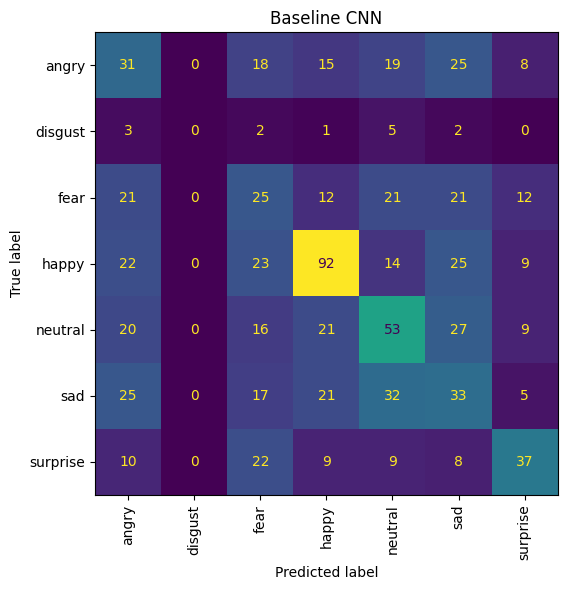

,class_id,class_name,support,correct,accuracy
1,1,disgust,13,0,0.000000
2,2,fear,112,25,0.223214
5,5,sad,133,33,0.248120
0,0,angry,116,31,0.267241
4,4,neutral,146,53,0.363014
6,6,surprise,95,37,0.389474
3,3,happy,185,92,0.497297


,true_class,predicted_class,count
28,sad,neutral,32
23,neutral,sad,27
3,angry,sad,25
25,sad,angry,25
18,happy,sad,25
16,happy,fear,23
31,surprise,fear,22
15,happy,angry,22
12,fear,neutral,21
27,sad,happy,21


In [14]:
base_cm = plot_confusion_matrix(
    y_val_small_v1,
    base_y_pred,
    class_names,
    title="Baseline CNN"
)

base_per_class = calculate_per_class_accuracy(
    base_cm,
    class_names
)

display(base_per_class)

base_confusions = get_most_confused_pairs(
    base_cm,
    class_names
)

display(base_confusions)

Antal felklassificerade exempel: 529
Andel felklassificerade: 66.12%


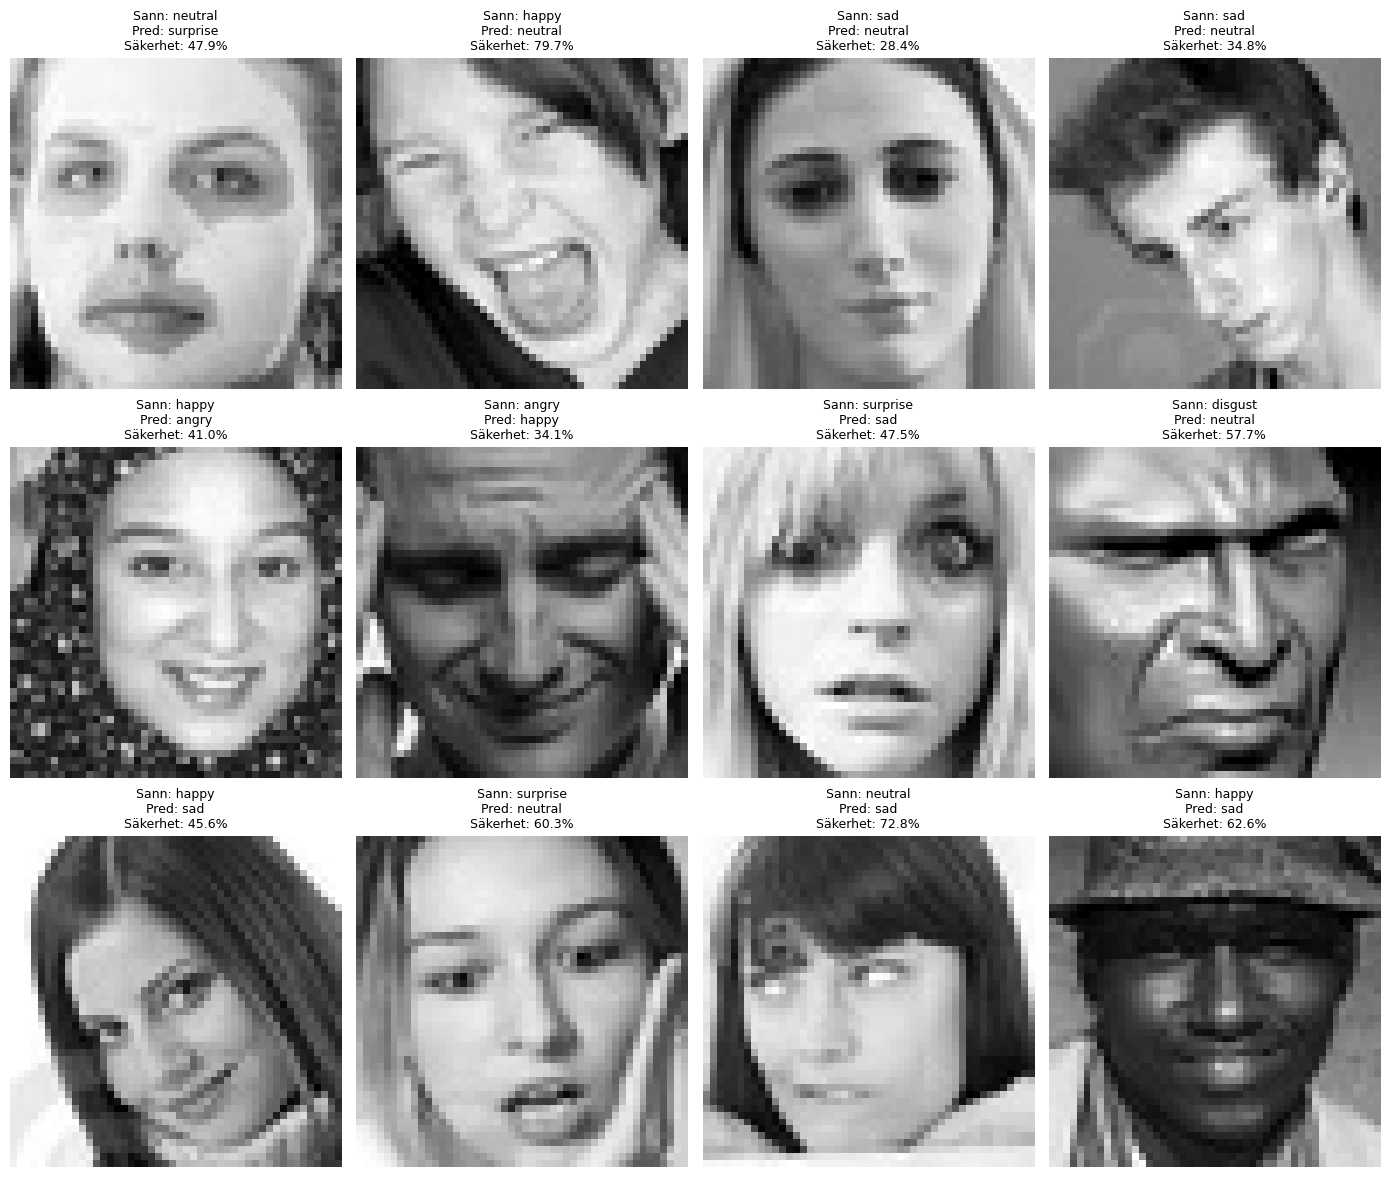

In [15]:
plot_misclassified_examples(
    X_val_small_v1,
    y_val_small_v1,
    base_y_pred,
    base_y_proba,
    class_names,
    n_images=12,
    random_state=42
)

In [16]:
results.append({
    "model": "baseline",
    "val_acc": base_val_acc,
    "val_loss": base_history_df["val_loss"].min(),
    "epochs_trained": len(base_history_df),
    "training_time_min": training_time / 60
})

results_df = pd.DataFrame(results)
display(results_df)

,model,val_acc,val_loss,epochs_trained,training_time_min
0,baseline,0.33875,1.616598,10,0.294383


### 3.2.4 Sammanfattning av baseline-modellen

Baseline-modellen lyckas lära sig grundläggande mönster i datan men visar tydliga tecken på overfitting.

Genomgången av felklassificeringarna och klassprestandan visar tre tydliga mönster:

- Klassobalansens påverkan: Modellen presterar bäst på de dominerande majoritetsklasserna (såsom happy), medan minoritetsklasser som har väldigt få träningsbilder (särskilt disgust) har extremt svårt att få några rätta prediktioner.

- Visuella förväxlingar: Modellen blandar ofta ihop känslouttryck som är visuellt likartade och flera av de felklassificerade exempel innehåller uttryck som även för människor kan vara svåra att tolka tydligt.

- Överdriven säkerhet: I flera fall gör modellen felaktiga prediktioner med en relativt hög säkerhet, vilket tyder på att modellen ännu inte generaliserar tillräckligt bra.


Resultatet visar samtidigt att modellen fungerar som en bra grund för vidare förbättringar


### 3.3.1 Improved CNN 

För att minska overfitting och förbättra modellens generalisering testas en mer avancerad CNN-modell 

Jämfört med baseline-modellen används:
- fler convolutional layers
- dropout
- ett större dataset

Dropout används för att minska risken att modellen anpassar sig för mycket till träningsdatan och därmed förbättra generaliseringsförmågan.

In [17]:
improved_model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(48, 48, 1)),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(num_classes, activation='softmax')
])

improved_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

improved_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,245,671 (4.75 MB)

 Trainable params: 1,245,671 (4.75 MB)

 Non-trainable params: 0 (0.00 B)

### 3.3.2 Träning av den förbättrade modellen

Den förbättrade modellen tränas på den större dataset-versionen (small_v2) för att ge modellen tillgång till mer träningsdata.

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.2400 - loss: 1.8417 - val_accuracy: 0.2488 - val_loss: 1.8230
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.2605 - loss: 1.7975 - val_accuracy: 0.2919 - val_loss: 1.7461
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.2894 - loss: 1.7420 - val_accuracy: 0.3363 - val_loss: 1.6897
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.3445 - loss: 1.6712 - val_accuracy: 0.3656 - val_loss: 1.6285
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.3698 - loss: 1.6023 - val_accuracy: 0.4006 - val_loss: 1.5629
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.4002 - loss: 1.5400 - val_accuracy: 0.3969 - val_loss: 1.5267
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.4247 - loss: 1.4837 - val_accuracy: 0.4313 - val_loss: 1.4773
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.4530 - loss: 1.4166 - val_accu

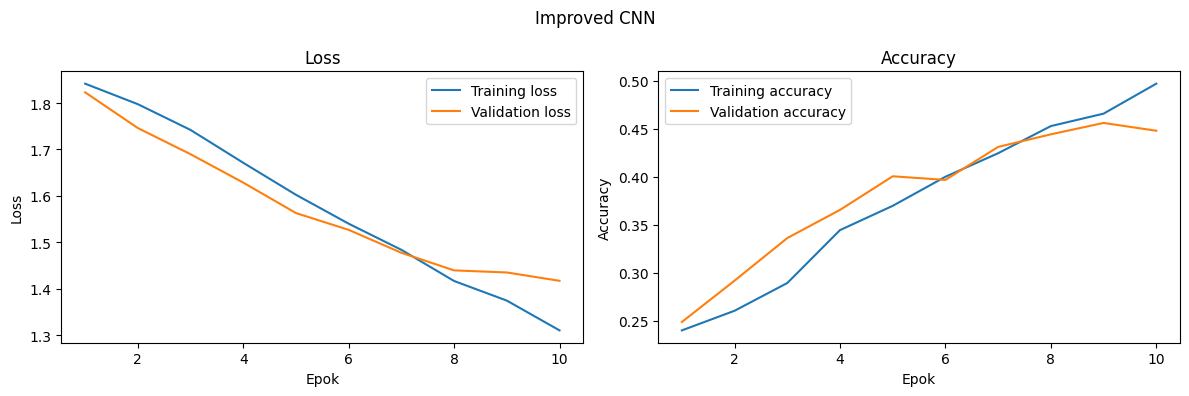

In [18]:
start_time = time.time()

improved_history = improved_model.fit(
    train_dataset_small_v2,
    validation_data=validation_dataset_small_v2,
    epochs=10
)

training_time = time.time() - start_time

print(f'Träningstid: {training_time / 60:.2f} minuter')

plot_history(improved_history, title="Improved CNN")

### 3.3.3 Observationer från träningen

Modellen förbättras successivt under hela träningen och både tränings- och validation accuracy ökar stabilt över flera epoker.

Till skillnad från baseline-modellen syns mindre tydliga tecken på overfitting, vilket tyder på att dropout och den större datamängden bidrar till bättre generalisering.

Validation loss fortsätter dessutom att minska genom större delen av träningen, vilket indikerar att modellen fortfarande lär sig relevanta mönster i datan.

In [19]:
improved_history_df = pd.DataFrame(improved_history.history)

best_epoch = improved_history_df['val_loss'].idxmin() + 1
best_val_loss = improved_history_df['val_loss'].min()
best_val_accuracy = improved_history_df['val_accuracy'].iloc[best_epoch - 1]

print(f'Bästa validation loss vid epok: {best_epoch}')
print(f'Bästa validation loss: {best_val_loss:.4f}')
print(f'Validation accuracy vid den epoken: {best_val_accuracy:.4f}')

improved_y_pred, improved_y_proba = predict_classes(
    improved_model,
    X_val_small_v2
)

improved_val_acc = accuracy_score(y_val_small_v2, improved_y_pred)

print(f"Improved validation accuracy: {improved_val_acc:.4f}")

Bästa validation loss vid epok: 10
Bästa validation loss: 1.4170
Validation accuracy vid den epoken: 0.4481
Improved validation accuracy: 0.4412


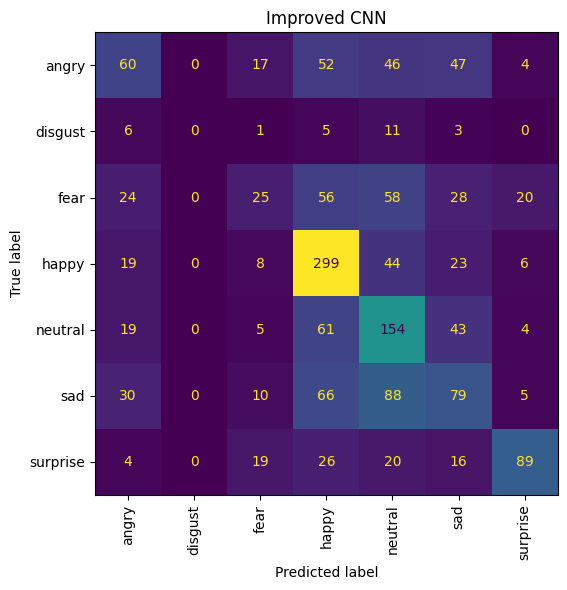

,class_id,class_name,support,correct,accuracy
1,1,disgust,26,0,0.000000
2,2,fear,211,25,0.118483
0,0,angry,226,60,0.265487
5,5,sad,278,79,0.284173
6,6,surprise,174,89,0.511494
4,4,neutral,286,154,0.538462
3,3,happy,399,299,0.749373


,true_class,predicted_class,count
28,sad,neutral,88
27,sad,happy,66
22,neutral,happy,61
12,fear,neutral,58
11,fear,happy,56
1,angry,happy,52
3,angry,sad,47
2,angry,neutral,46
17,happy,neutral,44
23,neutral,sad,43


In [20]:
improved_cm = plot_confusion_matrix(
    y_val_small_v2,
    improved_y_pred,
    class_names,
    title="Improved CNN"
)

improved_per_class = calculate_per_class_accuracy(
    improved_cm,
    class_names
)

display(improved_per_class)

improved_confusions = get_most_confused_pairs(
    improved_cm,
    class_names
)

display(improved_confusions)

Antal felklassificerade exempel: 894
Andel felklassificerade: 55.88%


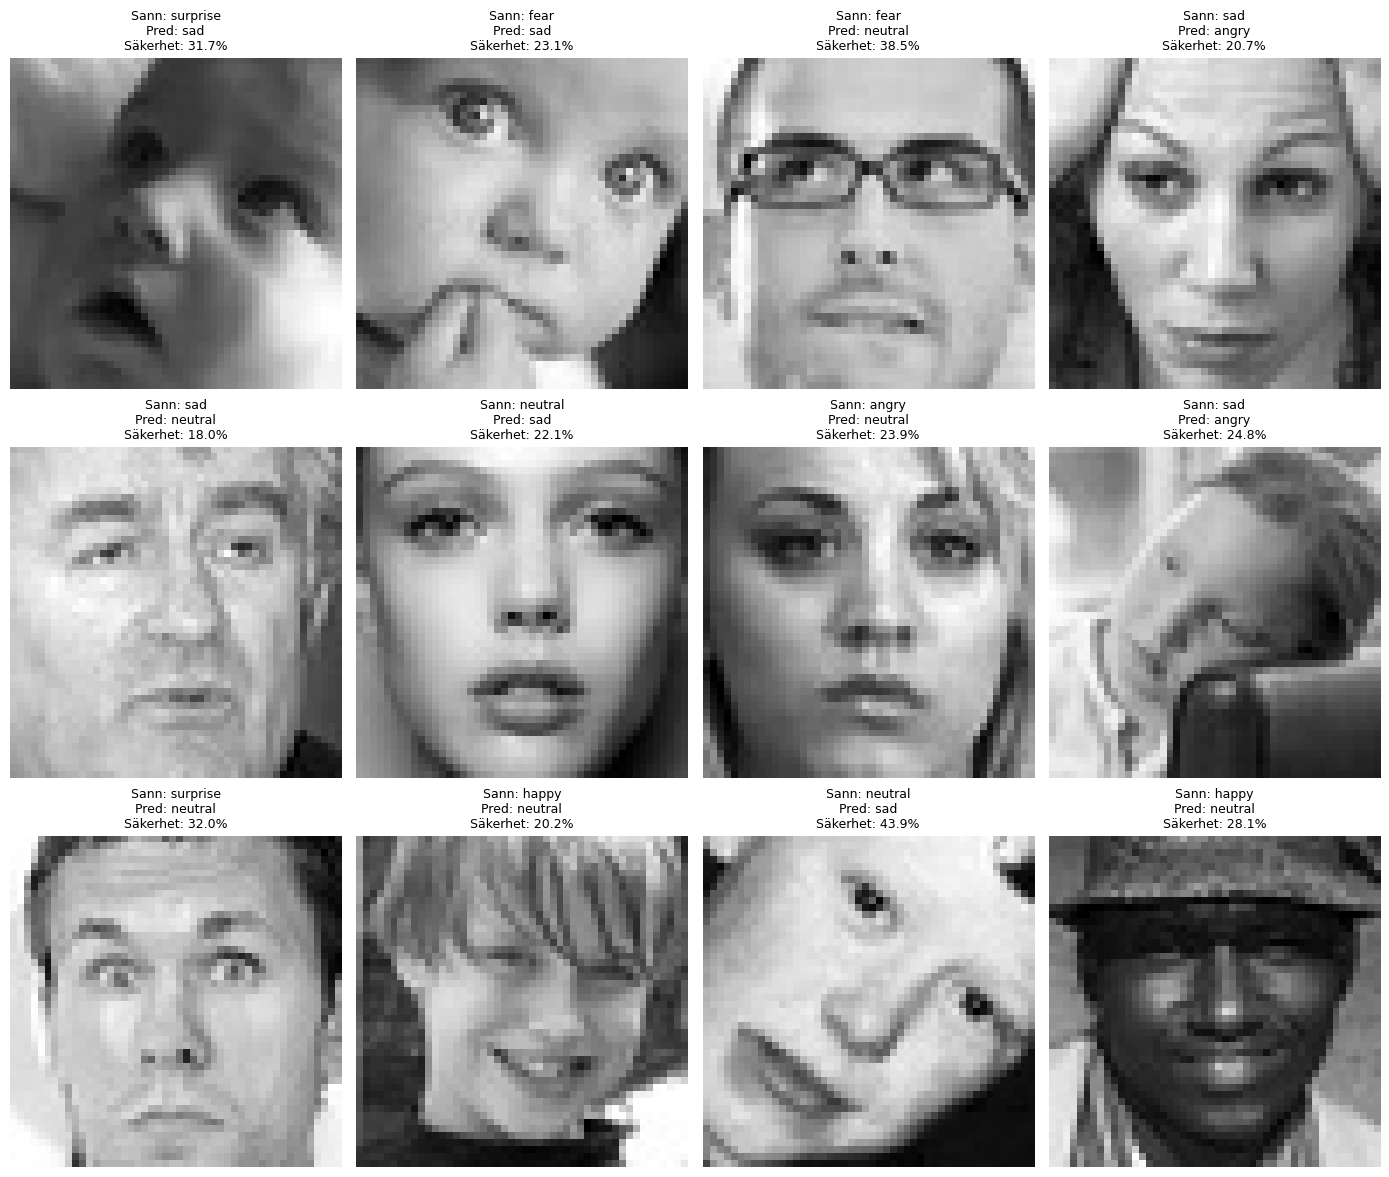

In [21]:
plot_misclassified_examples(
    X_val_small_v2,
    y_val_small_v2,
    improved_y_pred,
    improved_y_proba,
    class_names,
    n_images=12,
    random_state=42
)

In [22]:
results.append({
    "model": "improved",
    "val_acc": improved_val_acc,
    "val_loss": improved_history_df["val_loss"].min(),
    "epochs_trained": len(improved_history_df),
    "training_time_min": training_time / 60
})

results_df = pd.DataFrame(results)
display(results_df)

,model,val_acc,val_loss,epochs_trained,training_time_min
0,baseline,0.33875,1.616598,10,0.294383
1,improved,0.44125,1.416966,10,1.150866


### 3.3.4 Sammanfattning av improved-modellen

Den förbättrade modellen uppnår högre validation accuracy och lägre validation loss jämfört med baseline-modellen.  
Träningskurvorna ligger närmare varandra, vilket visar att dropout och mer data har minskat overfittingen.

De viktigaste upptäckterna från analysen är:

- **Bäst på stora klasser:** Modellen har blivit mycket bättre på de klasser som har många bilder (som happy och surprise).

- **Svårt för små klasser:** De klasser som har väldigt få bilder (disgust och fear) är fortfarande jättesvåra för modellen att gissa rätt på.

- **Gissar ofta på "neutral":** Det absolut vanligaste felet är att modellen gissar på neutral när den egentligen ser en ledsen (sad) eller arg (angry) person.

- **Tar längre tid:** Eftersom modellen har fler lager och mer data tar den också längre tid att träna.

**Slutsats:** Modellen har blivit mycket bättre på att hantera nya bilder, men klassobalansen är fortfarande ett problem.

### 3.4.1 Improved 2 CNN - större datamängd och Early Stopping

I denna version behålls samma grundarkitektur som i föregående modell, men modellen tränas nu på hela träningsdatan istället för ett mindre subset.

Målet är att undersöka om mer träningsdata kan förbättra modellens generaliseringsförmåga och ge stabilare resultat.

För att minska risken för overfitting används även `EarlyStopping`, vilket avbryter träningen när validation loss slutar förbättras och återställer modellens bästa vikter.

En möjlig förbättring hade varit att testa en djupare modellarkitektur, men eftersom modellen redan visar tillräcklig kapacitet ligger fokus här istället på datamängd och regularisering.

Jämfört med tidigare modeller används:
- hela träningsdatasetet
- EarlyStopping
- samma CNN-arkitektur med dropout

In [23]:
improved2_model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(48, 48, 1)),

    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(num_classes, activation='softmax')
])

improved2_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

improved2_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,245,671 (4.75 MB)

 Trainable params: 1,245,671 (4.75 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

### 3.4.2 Träning av Improved 2-modellen

Modellen tränas på hela träningsdatan med maximalt 20 epoker och earlystopping

Epoch 1/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - accuracy: 0.2652 - loss: 1.7914 - val_accuracy: 0.3590 - val_loss: 1.6566
Epoch 2/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 24s 33ms/step - accuracy: 0.3711 - loss: 1.6059 - val_accuracy: 0.4299 - val_loss: 1.4789
Epoch 3/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.4392 - loss: 1.4597 - val_accuracy: 0.4783 - val_loss: 1.3602
Epoch 4/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 24s 33ms/step - accuracy: 0.4712 - loss: 1.3772 - val_accuracy: 0.5083 - val_loss: 1.3034
Epoch 5/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.4928 - loss: 1.3214 - val_accuracy: 0.5158 - val_loss: 1.2625
Epoch 6/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 26s 36ms/step - accuracy: 0.5156 - loss: 1.2747 - val_accuracy: 0.5180 - val_loss: 1.2446
Epoch 7/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.5316 - loss: 1.2414 - val_accuracy: 0.5288 - val_loss: 1.2278
Epoch 8/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.5431 - loss: 1.2001 - 

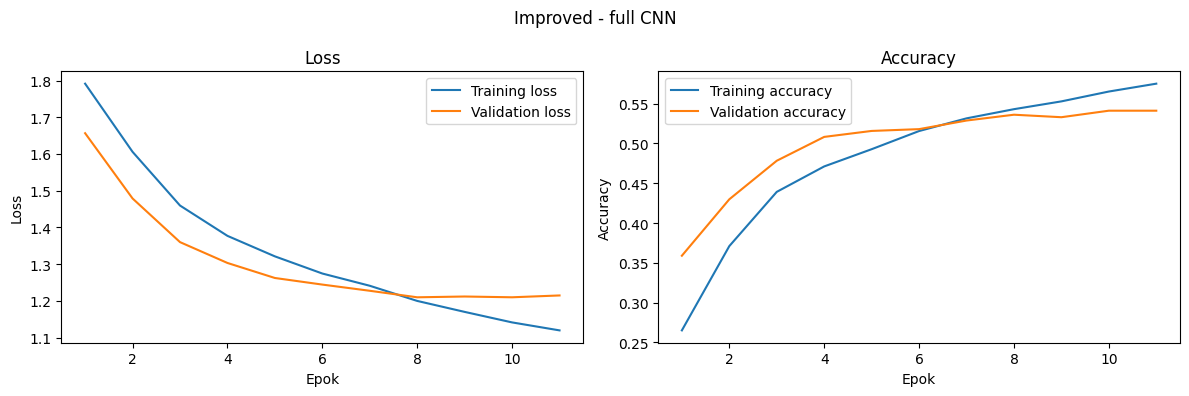

In [25]:
start_time = time.time()

improved2_history = improved2_model.fit(
    train_dataset_full,
    validation_data=validation_dataset_full,
    epochs=20,
    callbacks=[early_stop]
)

training_time = time.time() - start_time

print(f'Träningstid: {training_time / 60:.2f} minuter')

plot_history(improved2_history, title='Improved - full CNN')

### 3.4.3 Observationer från träningen

Modellen förbättras stabilt under större delen av träningen och både tränings- och validation accuracy ökar successivt över flera epoker.

Validation loss fortsätter dessutom att minska under lång tid, vilket tyder på att den större datamängden hjälper modellen att generalisera bättre än tidigare modeller.

Mot slutet av träningen börjar förbättringarna plana ut samtidigt som skillnaden mellan tränings- och validation accuracy ökar något. Detta indikerar att modellen börjar närma sig overfitting, men att EarlyStopping hjälper till att begränsa problemet.

Överlag visar träningskurvorna en stabilare och mer robust inlärning jämfört med tidigare modeller.

In [26]:
improved2_history_df = pd.DataFrame(improved2_history.history)

best_epoch = improved2_history_df['val_loss'].idxmin() + 1
best_val_loss = improved2_history_df['val_loss'].min()
best_val_accuracy = improved2_history_df['val_accuracy'].iloc[best_epoch - 1]

print(f'Bästa validation loss vid epok: {best_epoch}')
print(f'Bästa validation loss: {best_val_loss:.4f}')
print(f'Validation accuracy vid den epoken: {best_val_accuracy:.4f}')


improved2_y_pred, improved2_y_proba = predict_classes(
    improved2_model,
    X_val_full
)

improved2_val_acc = accuracy_score(y_val_full, improved2_y_pred)

print(f"Improved2 validation accuracy: {improved2_val_acc:.4f}")

Bästa validation loss vid epok: 8
Bästa validation loss: 1.2100
Validation accuracy vid den epoken: 0.5361
Improved2 validation accuracy: 0.5361


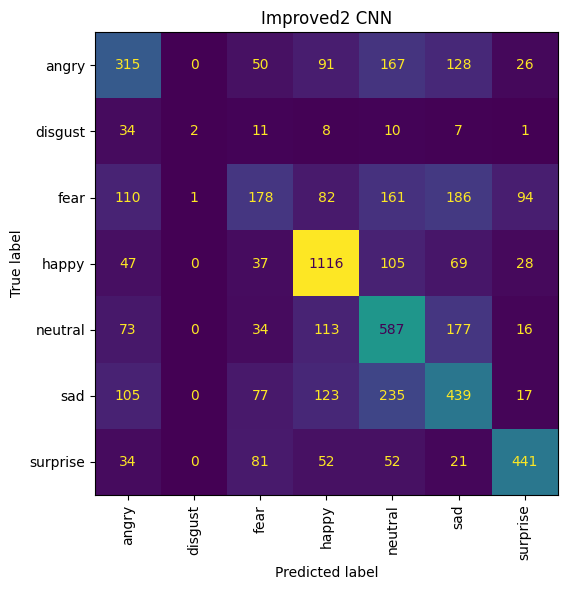

,class_id,class_name,support,correct,accuracy
1,1,disgust,73,2,0.027397
2,2,fear,812,178,0.219212
0,0,angry,777,315,0.405405
5,5,sad,996,439,0.440763
4,4,neutral,1000,587,0.587000
6,6,surprise,681,441,0.647577
3,3,happy,1402,1116,0.796006


,true_class,predicted_class,count
30,sad,neutral,235
15,fear,sad,186
25,neutral,sad,177
2,angry,neutral,167
14,fear,neutral,161
3,angry,sad,128
29,sad,happy,123
24,neutral,happy,113
11,fear,angry,110
27,sad,angry,105


In [27]:
improved2_cm = plot_confusion_matrix(
    y_val_full,
    improved2_y_pred,
    class_names,
    title="Improved2 CNN"
)

improved2_per_class = calculate_per_class_accuracy(
    improved2_cm,
    class_names
)

display(improved2_per_class)

improved2_confusions = get_most_confused_pairs(
    improved2_cm,
    class_names
)

display(improved2_confusions)

Antal felklassificerade exempel: 2663
Andel felklassificerade: 46.39%


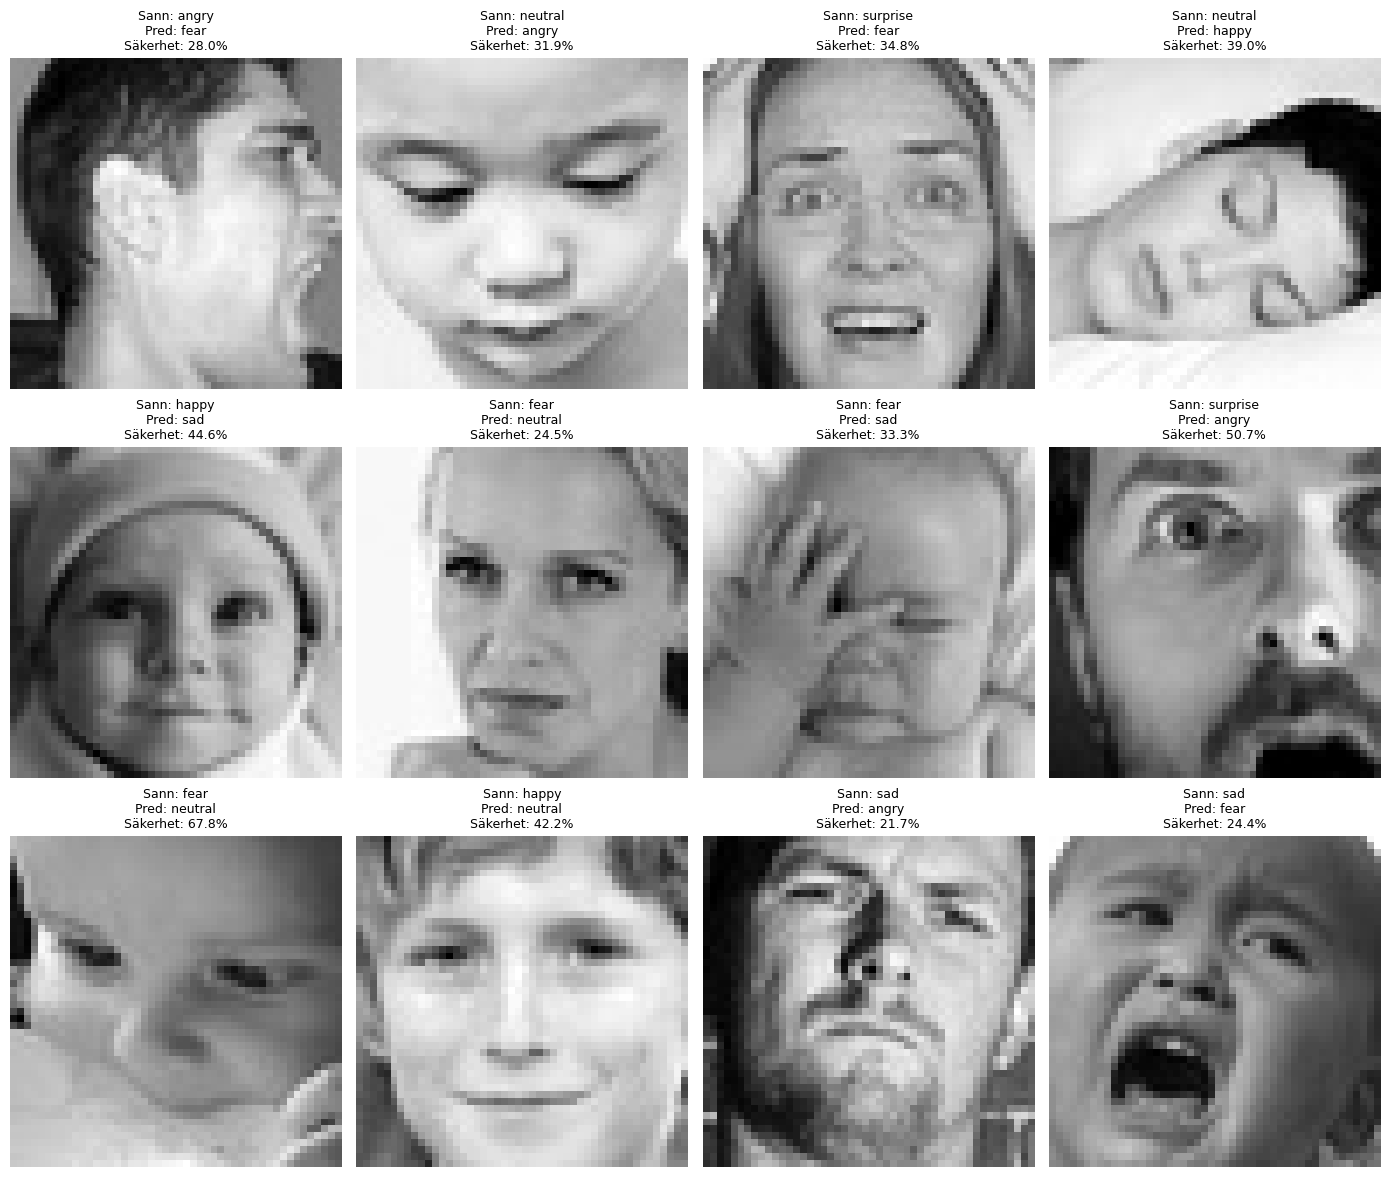

In [28]:
plot_misclassified_examples(
    X_val_full,
    y_val_full,
    improved2_y_pred,
    improved2_y_proba,
    class_names,
    n_images=12,
    random_state=42
)

In [29]:
results.append({
    "model": "improved_2",
    "val_acc": improved2_val_acc,
    "val_loss": improved2_history_df["val_loss"].min(),
    "epochs_trained": len(improved2_history_df),
    "training_time_min": training_time / 60
})

results_df = pd.DataFrame(results)
display(results_df)

,model,val_acc,val_loss,epochs_trained,training_time_min
0,baseline,0.338750,1.616598,10,0.294383
1,improved,0.441250,1.416966,10,1.150866
2,improved_2,0.536144,1.209992,11,4.706650


### 3.4.4 Sammanfattning av Improved 2-modellen

3.4.4 Sammanfattning av Improved 2-modellen
Genom att använda hela datasetet och Early Stopping har modellen nått sina bästa resultat hittills. Träningskurvorna visar en mycket stabilare inlärning, och Early Stopping avbröt träningen i rätt tid (vid epok 15) för att förhindra att modellen började overfitta.

De viktigaste upptäckterna från analysen är:

- **Stor nytta av mer data:** Modellen blev mycket säkrare och bättre på nästan alla klasser när den fick se alla bilder. Happy och surprise är fortfarande modellens starkaste klasser.

- **Framsteg för små klasser:** Den minsta klassen (disgust) lyckas nu få en del rätt, även om den och fear fortfarande är de svåraste klasserna.

- **Nya felmönster:** Modellen blandar fortfarande ihop sad och neutral, men ett nytt vanligt fel är att den också blandar ihop fear och sad.

- **Längre träningstid:** Eftersom modellen tränas på hela datasetet tog träningen betydligt längre tid (nästan 7 minuter), vilket visar att mer data kräver mer datorkraft.

**Slutsats:** Att skala upp datamängden var det som gav störst effekt på modellens prestanda. Modellen är nu mycket mer robust, men har fortfarande svårt med vissa visuellt lika ansiktsuttryck.

### 3.5.1 Final CNN - test av data augmentation

I denna modell testas data augmentation för att undersöka om modellen kan generalisera bättre genom att tränas på varierade versioner av bilderna.

Augmentation används endast på träningsdatan och består av:
- horisontell spegling
- mindre rotationer
- mindre zoomförändringar

Tanken är att modellen ska bli mindre känslig för små variationer i ansikten och därmed prestera bättre på ny data.
Övrig arkitektur behålls från föregående modell för att isolera effekten av data augmentation.



In [30]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal", seed=42),
    tf.keras.layers.RandomRotation(0.1, seed=42),
    tf.keras.layers.RandomZoom(0.1, seed=42),
])

In [31]:
final_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(48, 48, 1)),

    data_augmentation,

    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(num_classes, activation='softmax')
])

final_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

### 3.5.2 Träning av finalmodellen

Finalmodellen tränades initialt med samma inställningar som föregående modell, men med dataaugmentation aktiverad.  

Under den första träningen avbröts modellen redan efter 3 epoker på grund av early stopping, vilket tydde på att träningen stoppades för tidigt. För att ge modellen mer tid att lära sig ökades därför `patience` från 3 till 5.

Eftersom dataaugmentation gör träningsdatan mer varierad och svårare att lära sig från, skedde inlärningen långsammare än tidigare. Antalet epoker ökades därför till 40 för att modellen skulle få tillräckligt med tid att träna.

In [32]:
early_stop_2 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

Epoch 1/40
718/718 ━━━━━━━━━━━━━━━━━━━━ 30s 40ms/step - accuracy: 0.2491 - loss: 1.8117 - val_accuracy: 0.2620 - val_loss: 1.7803
Epoch 2/40
718/718 ━━━━━━━━━━━━━━━━━━━━ 30s 41ms/step - accuracy: 0.2703 - loss: 1.7649 - val_accuracy: 0.3196 - val_loss: 1.6914
Epoch 3/40
718/718 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.3047 - loss: 1.7191 - val_accuracy: 0.3496 - val_loss: 1.6503
Epoch 4/40
718/718 ━━━━━━━━━━━━━━━━━━━━ 28s 38ms/step - accuracy: 0.3419 - loss: 1.6561 - val_accuracy: 0.3980 - val_loss: 1.5271
Epoch 5/40
718/718 ━━━━━━━━━━━━━━━━━━━━ 28s 38ms/step - accuracy: 0.3750 - loss: 1.5906 - val_accuracy: 0.4304 - val_loss: 1.4607
Epoch 6/40
718/718 ━━━━━━━━━━━━━━━━━━━━ 30s 41ms/step - accuracy: 0.3965 - loss: 1.5436 - val_accuracy: 0.4346 - val_loss: 1.4448
Epoch 7/40
718/718 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.4141 - loss: 1.5085 - val_accuracy: 0.4520 - val_loss: 1.3937
Epoch 8/40
718/718 ━━━━━━━━━━━━━━━━━━━━ 32s 44ms/step - accuracy: 0.4260 - loss: 1.4807 - 

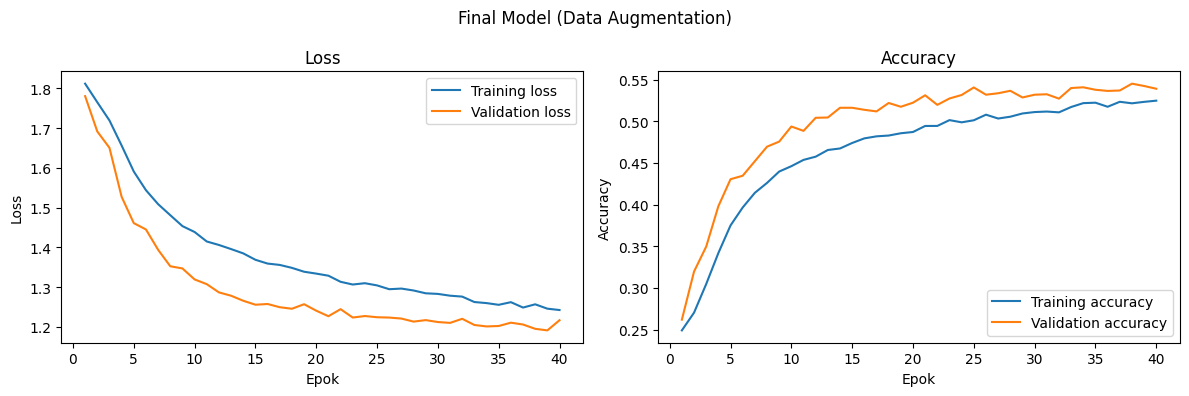

In [33]:
start_time = time.time()

final_history = final_model.fit(
    train_dataset_full,
    validation_data=validation_dataset_full,
    epochs=40,
    callbacks=[early_stop_2]
)

training_time = time.time() - start_time

print(f"Träningstid: {training_time/60:.2f} min")

plot_history(final_history, title="Final Model (Data Augmentation)")

### 3.5.3 Observationer från träningen

Observationer från träningen
Träningen tar längre tid: När data augmentation används blir varje epok svårare för modellen. Det gjorde att träningen tog betydligt längre tid och krävde att jag höjde patience och max antal epoker för att modellen inte skulle avbrytas för tidigt.

Valideringen ser bättre ut än träningen: I träningskurvorna kan vi se och tolka att validerings-accuracy ligger över tränings-accuracy, och validerings-loss ligger under tränings-loss. Detta beror på att träningsbilderna hela tiden förändras och blir svårare att lära sig, medan valideringsbilderna är stabila och "rena", vilket gör dem lättare för modellen under själva träningen.

In [34]:
final_history_df = pd.DataFrame(final_history.history)

best_epoch = final_history_df['val_loss'].idxmin() + 1
best_val_loss = final_history_df['val_loss'].min()
best_val_accuracy = final_history_df['val_accuracy'].iloc[best_epoch - 1]

print(f'Bästa validation loss vid epok: {best_epoch}')
print(f'Bästa validation loss: {best_val_loss:.4f}')
print(f'Validation accuracy vid den epoken: {best_val_accuracy:.4f}')

final_y_pred, final_y_proba = predict_classes(final_model, X_val_full)
final_val_acc = accuracy_score(y_val_full, final_y_pred)

print(f'Final validation accuracy:, {final_val_acc:.4f}')

Bästa validation loss vid epok: 39
Bästa validation loss: 1.1909
Validation accuracy vid den epoken: 0.5422
Final validation accuracy:, 0.5422


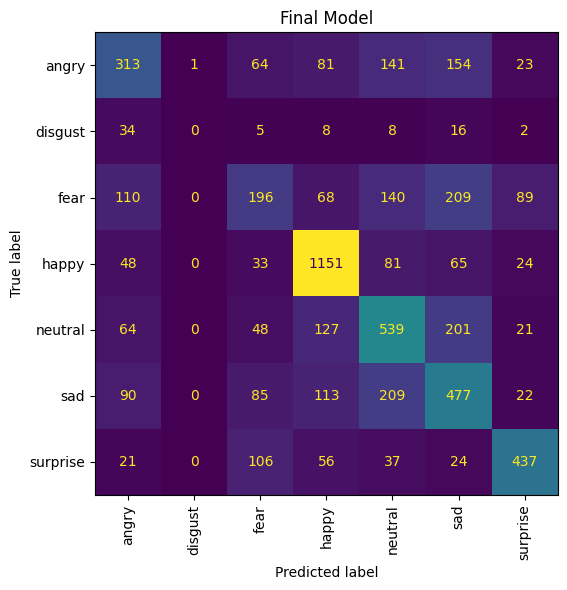

,class_id,class_name,support,correct,accuracy
1,1,disgust,73,0,0.000000
2,2,fear,812,196,0.241379
0,0,angry,777,313,0.402831
5,5,sad,996,477,0.478916
4,4,neutral,1000,539,0.539000
6,6,surprise,681,437,0.641703
3,3,happy,1402,1151,0.820970


,true_class,predicted_class,count
15,fear,sad,209
30,sad,neutral,209
25,neutral,sad,201
4,angry,sad,154
3,angry,neutral,141
14,fear,neutral,140
24,neutral,happy,127
29,sad,happy,113
12,fear,angry,110
33,surprise,fear,106


In [35]:
final_cm = plot_confusion_matrix(
    y_val_full,
    final_y_pred,
    class_names,
    title="Final Model"
)


final_per_class = calculate_per_class_accuracy(
    final_cm, 
    class_names
    )

display(final_per_class)

final_confusions = get_most_confused_pairs(
    final_cm, 
    class_names
    )

display(final_confusions)


Antal felklassificerade exempel: 2628
Andel felklassificerade: 45.78%


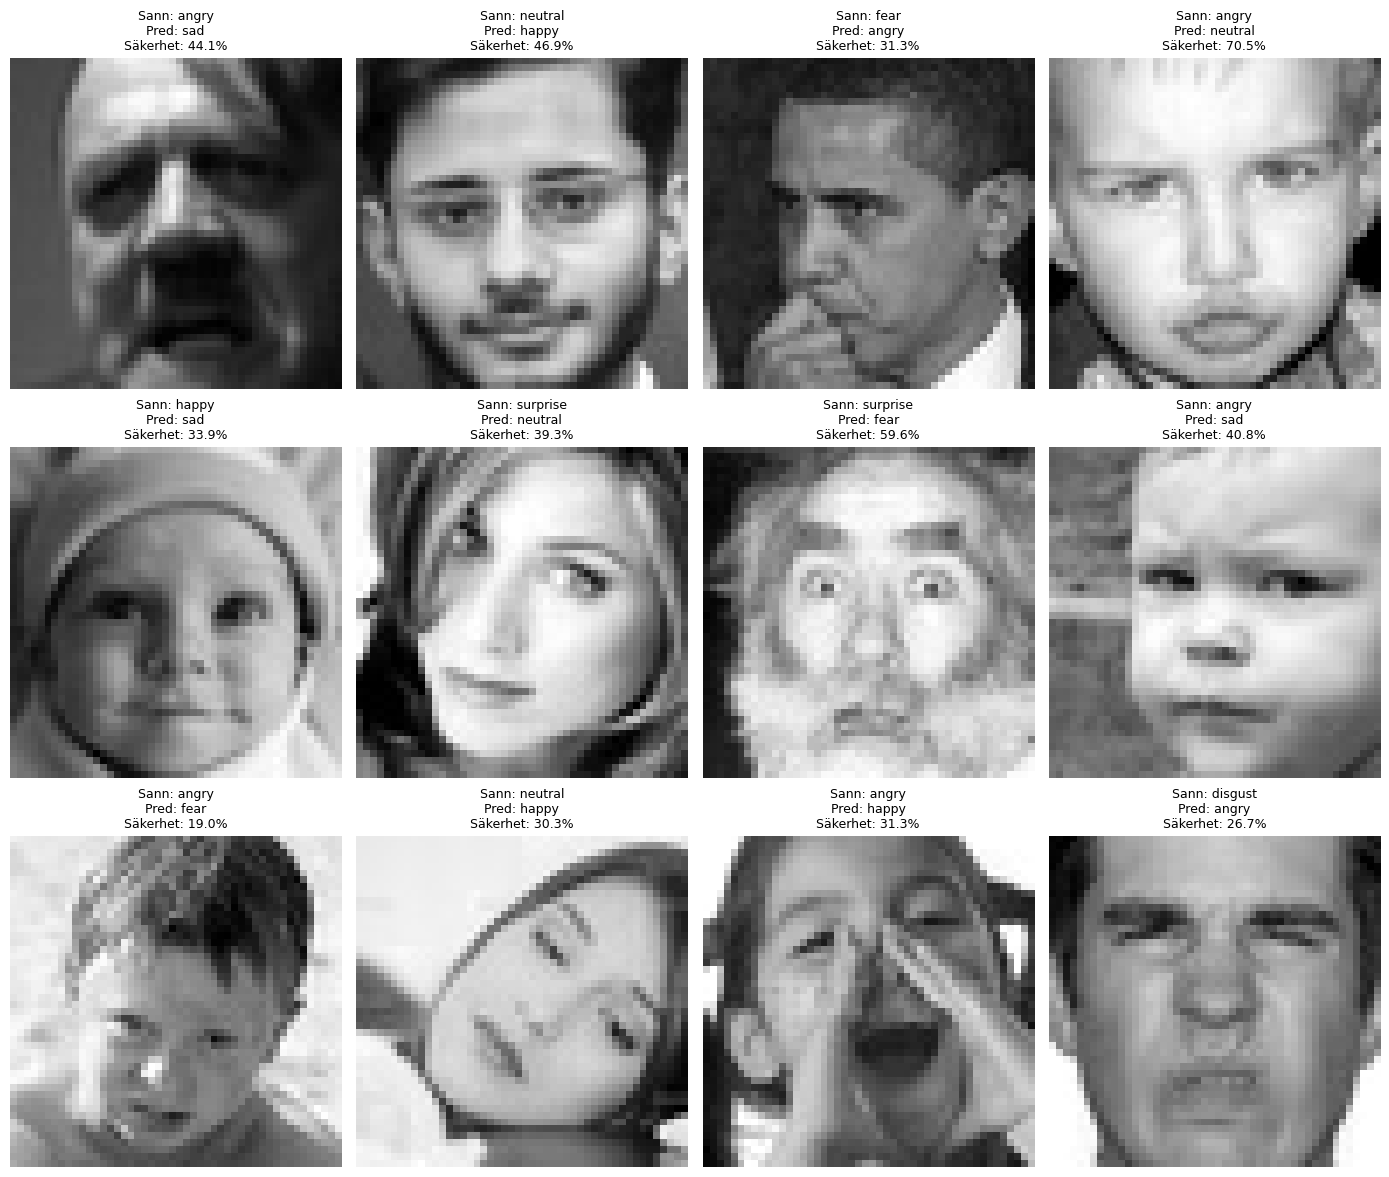

In [36]:
plot_misclassified_examples(
    X_val_full,
    y_val_full,
    final_y_pred,
    final_y_proba,
    class_names,
    n_images=12,
    random_state=42
)

In [37]:
results.append({
    "model": "final (augmentation)",
    "val_acc": final_val_acc,
    "val_loss": final_history_df["val_loss"].min(),
    "epochs_trained": len(final_history_df),
    "training_time_min": training_time / 60
})

results_df = pd.DataFrame(results)
display(results_df)

,model,val_acc,val_loss,epochs_trained,training_time_min
0,baseline,0.338750,1.616598,10,0.294383
1,improved,0.441250,1.416966,10,1.150866
2,improved_2,0.536144,1.209992,11,4.706650
3,final (augmentation),0.542240,1.190853,40,20.189129


### 3.5.4 Sammanfattning av finalmodellen
Finalmodellen med data augmentation nådde inte riktigt lika bra resultat på valideringsdatan som vår förra modell (Improved 2).

De viktigaste upptäckterna från analysen är:

- **Lågupplösta bilder blir för svåra:** Eftersom bilderna i datasetet redan är väldigt små och lågupplösta (48x48 pixlar), gör funktioner som zoom och rotation att bilderna blir ännu mer suddiga. Istället för att hjälpa modellen gör detta att viktig information går förlorad och träningen blir för svår.

- **Bäst på stora klasser:** Modellen är fortfarande bäst på de klasser som har flest bilder (som happy och surprise), medan de minsta klasserna fortfarande är mycket svåra.

- **Vanliga felmönster:** Modellen blandar fortfarande ofta ihop känslor som liknar varandra rent visuellt, och tenderar att gissa på de större klasserna när den är osäker.

**Slutsats:** Data augmentation gjorde träningen svårare och tog mer tid, utan att ge bättre resultat på valideringsdatan. Det visar att data augmentation inte alltid är rätt verktyg, särskilt inte när bilderna redan har en väldigt låg upplösning från början.3



### 3.6 Sutlig jämförelsetabell 

In [38]:
# 1. Sortera tabellen så att modellen med högst validation accuracy hamnar överst
results_sorted = results_df.sort_values(by="val_acc", ascending=False).reset_index(drop=True)

# 2. Skapa en snygg färgmarkering för bästa modell (högst acc, lägst loss)
def highlight_best_model(row):
    # Eftersom tabellen är sorterad efter val_acc är index 0 alltid bäst
    if row.name == 0:
        return ['background-color: #d4edda; font-weight: bold; color: #155724'] * len(row)
    return [''] * len(row)

# 3. Visa den färdiga tabellen
print("=== RANGORDNING AV MODELLER (BÄST ÖVERST) ===")
results_sorted.style.apply(highlight_best_model, axis=1).format({
    'val_acc': '{:.4f}',
    'val_loss': '{:.4f}',
    'training_time_min': '{:.2f} min'
})

=== RANGORDNING AV MODELLER (BÄST ÖVERST) ===


,model,val_acc,val_loss,epochs_trained,training_time_min
0,final (augmentation),0.5422,1.1909,40,20.19 min
1,improved_2,0.5361,1.2100,11,4.71 min
2,improved,0.4412,1.4170,10,1.15 min
3,baseline,0.3387,1.6166,10,0.29 min


### 3.7 Slutgiltig jämförelse och val av bästa modell
Efter att ha testat och utvärderat fyra olika modeller i en tabell, kan vi se tydliga mönster i hur de har presterat:

Baseline CNN: Tränades snabbt på en liten del av datan. Den visade tydliga tecken på overfitting eftersom den blev jättebra på träningsdatan men stannade av helt på valideringsdatan. Den hade också 0 % rätt på den minsta klassen (disgust).

Improved CNN: Genom att lägga till fler lager och dropout lyckades vi minska överanpassningen. Precisionen ökade direkt och modellen blev mycket bättre på att hantera nya bilder.

Improved 2 CNN (Bästa modell): Genom att använda hela datasetet och Early Stopping fick vi modellens absolut bästa resultat. Träningskurvorna blev stabila och modellen lyckades för första gången få en del rätt även på de svåraste minoritetsklasserna. Early Stopping avbröt träningen i perfekt tid för att förhindra overfitting.

Final Model (Data Augmentation): Att förändra träningsbilderna genom zoom och rotation gjorde tyvärr modellen sämre. Eftersom bilderna redan är så små (48x48 pixlar) förstörde förvrängningarna den lilla information som fanns, vilket gjorde träningen för svår och långsam.

**Motivering av val av bästa modell**
Jag väljer Improved 2 CNN som min slutgiltiga modell för att göra prediktioner och utvärdera på testdatan.
Motivering:
Modellen har den högsta accuracyn och den lägsta lossen på valideringsdatan av alla modeller.   
Genom att träna på hela datasetet med dropout och Early Stopping har den fått den bästa balansen mellan att pricka rätt på de flera av de stora klasserna och även klara några av de mindre.


## 4. Spara och ladda bästa modell
Här sparas den bästa modellen (Improved 2) till en fil.   
Detta görs för att vi ska kunna ladda in exakt rätt vikter och använda modellen i framtiden utan att behöva träna om den.

In [39]:
best_model = improved2_model

best_model.save("best_emotion_model.keras")
print("Modellen sparades!")


loaded_model = tf.keras.models.load_model("best_emotion_model.keras")
print("Modellen laddades!")

Modellen sparades!
Modellen laddades!


## 5. Utvärdering på testdata
Modellen utvärderas nu på testdatasetet. Denna data har modellen aldrig sett tidigare, vilket ger ett helt ärligt svar på hur bra modellen fungerar i verkligheten.

In [40]:
test_loss, test_accuracy = loaded_model.evaluate(test_dataset)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

# Extrahera dataset
X_test, y_test = extract_dataset(test_dataset)

test_y_pred, test_y_proba = predict_classes(
    loaded_model,
    X_test
)

test_acc = accuracy_score(y_test, test_y_pred)

print(f"Test accuracy: {test_acc:.4f}")

225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5362 - loss: 1.2024
Test loss: 1.2024
Test accuracy: 0.5362
Test accuracy: 0.5362


### 5.1 Felanalys på testdata
För att förstå modellens styrkor och svagheter på ny data analyserar vi en confusion matrix och tittar på exempel där modellen har gissat fel.

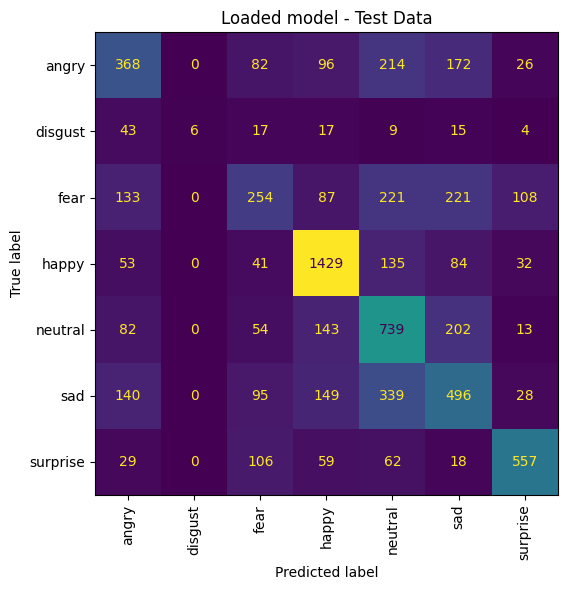

,class_id,class_name,support,correct,accuracy
1,1,disgust,73,0,0.000000
2,2,fear,812,196,0.241379
0,0,angry,777,313,0.402831
5,5,sad,996,477,0.478916
4,4,neutral,1000,539,0.539000
6,6,surprise,681,437,0.641703
3,3,happy,1402,1151,0.820970


,true_class,predicted_class,count
15,fear,sad,209
30,sad,neutral,209
25,neutral,sad,201
4,angry,sad,154
3,angry,neutral,141
14,fear,neutral,140
24,neutral,happy,127
29,sad,happy,113
12,fear,angry,110
33,surprise,fear,106


In [41]:
test_cm = plot_confusion_matrix(
    y_test,
    test_y_pred,
    class_names,
    title="Loaded model - Test Data"
)

test_per_class = calculate_per_class_accuracy(
    final_cm, 
    class_names
    )

display(test_per_class)

test_confusions = get_most_confused_pairs(
    final_cm, 
    class_names
    )

display(test_confusions)

Antal felklassificerade exempel: 3329
Andel felklassificerade: 46.38%


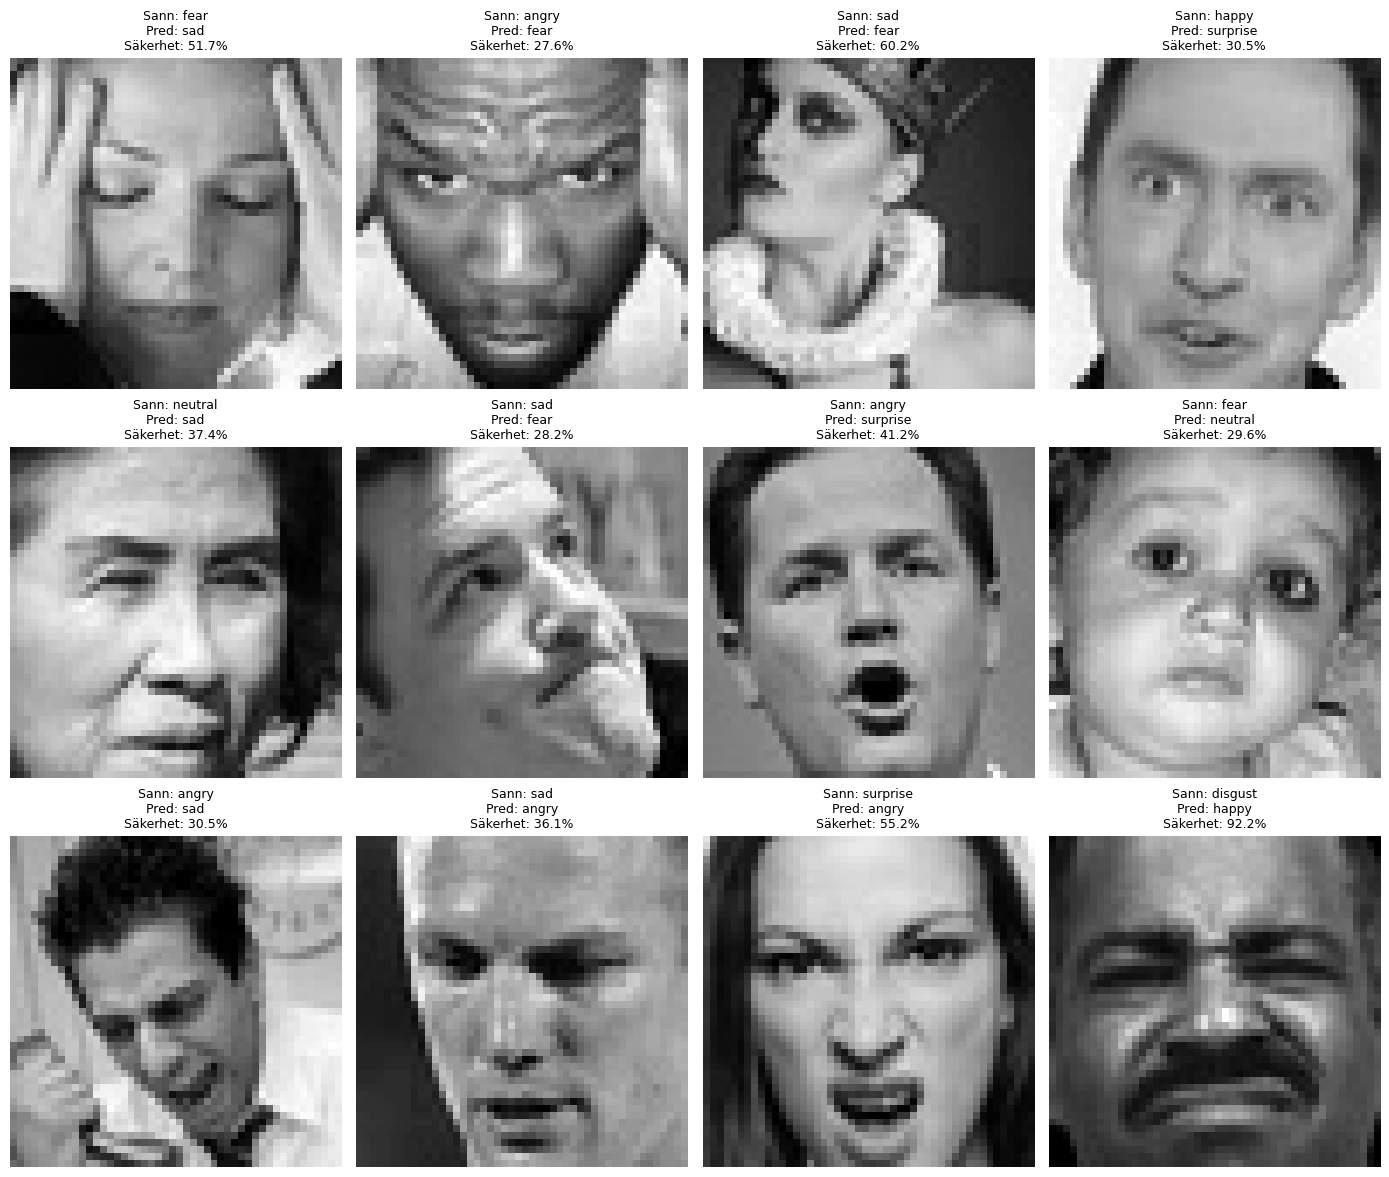

In [42]:
plot_misclassified_examples(
    X_test,
    y_test,
    test_y_pred,
    test_y_proba,
    class_names,
    n_images=12,
    random_state=42
)

## 5.2 Interaktivt sluttest
Här kan vi välja ut en specifik bild från testdatan med hjälp av dess index. Detta gör det möjligt att visuellt granska exakt hur modellen fördelar sina sannolikheter på enskilda ansikten, och se om modellen har hög eller låg säkerhet i sina gissningar.


In [43]:
print(f"För att välj en bild sätt index till en siffra mellan 0 och {len(X_test)-1}")

För att välj en bild sätt index till en siffra mellan 0 och 7177


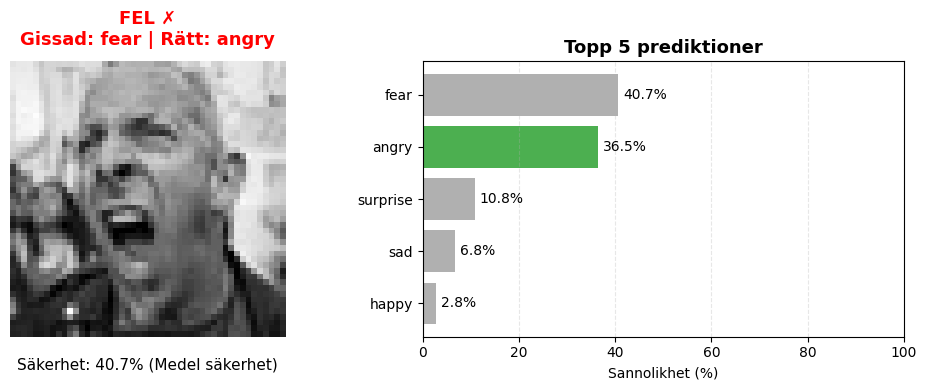

In [44]:
index = 7

show_prediction(
    image_index=index,
    X_data=X_test,
    y_data=y_test,
    y_proba=test_y_proba,  
    class_names=class_names
)